In [1]:
import numpy as np
# from numpy.fft import fft, fftfreq
from pyfftw.interfaces.numpy_fft import fft, fftfreq
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.signal.windows import blackman
from scipy.optimize import curve_fit

In [2]:
def format_data(data, data_gate, aclk_freq, words_per_packet, header_words):

    buffer_gate_np = np.array(data_gate)
    buffer_nonzero = buffer_gate_np[buffer_gate_np != 0]
    buffer_gate_np = None
    rising_edge_mask = ((buffer_nonzero & (1 << 63)) >> 63) == 0
    rising_edges = buffer_nonzero[rising_edge_mask]
    falling_edges = buffer_nonzero[~rising_edge_mask] & ((1 << 63) - 1)
    buffer_nonzero = None
    rising_edges = rising_edges.astype(np.float64) / aclk_freq
    falling_edges = falling_edges.astype(np.float64) / aclk_freq
    
    edge_times = np.array([rising_edges, falling_edges]).T
    rising_edges, falling_edges = None, None
    
    buffer_np = np.frombuffer(data, dtype=np.uint64)        
    
    num_words = buffer_np.size
    
    expected_magic_word_indices = np.arange(int(num_words / words_per_packet)) * words_per_packet
    expected_metadata_mask = np.full(buffer_np.size, False)
    expected_metadata_mask[expected_magic_word_indices] = True
    expected_magic_word_indices = None
    for _ in range(header_words-1):
        expected_metadata_mask |= np.roll(expected_metadata_mask, 1)
        
    first_ts = buffer_np[header_words-1]

    buffer_np = buffer_np[~expected_metadata_mask]
    buffer_np = np.frombuffer(buffer_np.byteswap(), dtype=np.uint8).reshape((-1,3)).astype(np.uint32)

    buffer_np = (buffer_np[:,0]<<16) + (buffer_np[:,1]<<8) + (buffer_np[:,2])

    buffer_np = buffer_np << 8
    buffer_np = buffer_np.astype(np.int32)
    buffer_np = buffer_np >> 8

    buffer_np = buffer_np.reshape((-1,8)).T
    
    return buffer_np, first_ts, edge_times

def process_to_dc(iq_data, samp_freq, fft_bins=1):

    num_samp = iq_data.shape[1]

    # Reshape the data so axis 1 indexes the different fft bins
    new_num_samps = num_samp - num_samp%fft_bins
    bin_samps = int(new_num_samps/fft_bins)
    iq_data = iq_data[:,:new_num_samps]
    iq_data = iq_data.reshape((-1,fft_bins,bin_samps))
    print(f'New number of samples (after FFT binning): {new_num_samps}')

    # Get FFT data and freq domain and sort (fftfreq doesn't give freqs back in ascending order)
    freq_domain = fftfreq(bin_samps, 1/samp_freq)
    freq_sort = np.argsort(freq_domain)
    freq_domain = freq_domain[freq_sort]
    iq_data_freq = fft(blackman(bin_samps)*iq_data, axis=2)[:,:,freq_sort]
    freq_sort = None

    if True:
        print('Finishesd FFTing')

    # Finds index of the highest-power signal (i.e. the carrier)
    carrier_indices = np.argmax(np.abs(iq_data_freq), axis=2)

    # Slices of indices immediately (3 away) around carrier index
    slices = carrier_indices[:,:,np.newaxis] + np.arange(-3, 4)[np.newaxis,np.newaxis,:]

    # Frequencies around carrier frequency
    freq_neighborhoods = freq_domain[slices]
  
    # FFT spectrum around carrier frequency
    iq_data_freq_neighborhoods = np.abs(np.take_along_axis(iq_data_freq, slices, axis=2))
    slices = None, None

    # Carrier frequency is found by weighted average of frequencies around the highest-power one. Since DC peak is not a delta, since if the true frequency is shifting, power is shifting among the FFT bins. 
    carrier_freqs = np.sum(freq_neighborhoods * iq_data_freq_neighborhoods/(np.sum(iq_data_freq_neighborhoods, axis=2)[:,:,np.newaxis]), axis=2)
    iq_data_freq_neighborhoods, freq_neighborhoods = None, None

    # Phases of the carrier signal
    carrier_phases = np.unwrap(np.angle(np.take_along_axis(iq_data_freq, carrier_indices[:,:,np.newaxis], axis=2))).squeeze(axis=2)
    iq_data_freq, carrier_indices = None, None

    # Down-mixes and eliminates any the phase due to the carrier
    iq_data = iq_data * np.exp(-1j * (2*np.pi*carrier_freqs[:,:,np.newaxis]/samp_freq*np.arange(bin_samps) + carrier_phases[:,:,np.newaxis]))
    carrier_freqs, carrier_phases = None, None

    # Takes away any remnant phases between I/Q data
    avg_phases = np.average(np.unwrap(np.angle(iq_data)), axis=2) # unwrap is very important here b/c we're averaging. if angle is fluctuating around +/- pi, the average of np.angle() could be ~0, but average of np.unwrap(np.angle()) will be the correct phase
    iq_data *= np.exp(-1j*avg_phases[:,:,np.newaxis])
    avg_phases = None

    iq_data = iq_data.reshape((-1, new_num_samps))

    return np.real(iq_data).astype(np.float64)    

def gate_means(data, times, gates):
    """
    data:  (4, N) detector data
    times: (N,)   sample times (constant spacing, assumed sorted)
    gates: (M, 2) [start, stop] times; uses start <= t < stop
    returns: (4, K) mean of data within each fully-contained gate, K <= M.
             Gates that are not fully covered by the data are dropped.
    """
    starts = gates[:, 0]
    stops = gates[:, 1]

    N = data.shape[1]
    lo = np.searchsorted(times, starts, side='left')
    hi = np.searchsorted(times, stops,  side='left')

    # A gate is fully contained iff:
    #   - its start is within the time range: start >= times[0]   -> lo < N (and start not before data)
    #   - its stop does not run past the data: hi < N (there is a sample at/after stop,
    #     meaning the data extends beyond the gate end)
    keep = (starts >= times[0]) & (hi < N) & (hi > lo)

    csum = np.concatenate(
        [np.zeros((data.shape[0], 1), dtype=np.float64),
         np.cumsum(data, axis=1, dtype=np.float64)],
        axis=1,
    )

    counts = hi - lo
    sums = csum[:, hi[keep]] - csum[:, lo[keep]]
    means = sums / counts[keep]

    return means

def plot_nice_ddf(ddfs, rdf1, rdf2, ch1_name, ch2_name, dir_path):

    fig, axs = plt.subplots(2,2, figsize=(10,8))
    fig.subplots_adjust(hspace=0)
    fig.subplots_adjust(wspace=0)

    n, bins, _ = axs[0,0].hist(rdf1, bins=100, histtype='step', color='purple', orientation='horizontal')
    axs[0,0].text(0.15*np.max(n), 0.85*bins[-1], f'$\\sigma={round(np.std(rdf1), 2)}$ ppm', fontdict=dict(size=14))
    axs[0,0].set_xscale('log')
    axs[0,0].minorticks_on()
    axs[0,0].xaxis.tick_top()
    axs[0,0].set_ylabel(f'{ch2_name} rel. diff. (ppm)')

    h = axs[0,1].hist2d(rdf1, rdf2, bins=100, cmap='turbo', norm=LogNorm())
    axs[0,1].set_xticks([])
    axs[0,1].set_yticks([])
    pos = axs[0, 1].get_position()

    # Create a new axis for the colorbar
    cbar_ax = fig.add_axes([
        pos.x1 + 0.01,  # x: slightly to the right of axs[0,1]
        pos.y0,         # y: same bottom as axs[0,1]
        0.02,           # width of colorbar
        pos.height      # same height as axs[0,1]
    ])
    fig.colorbar(h[3], cax=cbar_ax)

    n, bins, _ = axs[1,0].hist(ddfs, bins=100, histtype='step', color='purple')
    if np.std(ddfs) >= 0.5:
        bin_centers = (bins[:-1] + 0.5*np.diff(bins))
        def mygaussian(x, N, sigma, mu):
            return N/(sigma*np.sqrt(2*np.pi)) * np.exp(-0.5*(x-mu)*(x-mu)/(sigma*sigma))
        p0 = [np.sum(n), np.std(ddfs), 0]
        popt_ddf, pcov = curve_fit(mygaussian, bin_centers, n, p0=p0)
        mygauss_domain = np.linspace(bin_centers[0], bin_centers[-1], 300)
        axs[1,0].plot(mygauss_domain, mygaussian(mygauss_domain, *popt_ddf), color='teal')
    try:
        axs[1,0].text(0.2*bins[-1], 0.75*np.max(n), f'$\\sigma={round(popt_ddf[1], 2)}$ ppm', fontdict=dict(size=14))
        popt_ddf = None
    except:
        axs[1,0].text(0.2*bins[-1], 0.75*np.max(n), f'$\\sigma={round(np.std(ddfs), 2)}$ ppm', fontdict=dict(size=14))
        # axs[1,0].text(0.2*bins[-1], 0.75*np.max(n), f'$\\sigma={round(np.std(ddfs), 2)}$ ppm', fontdict=dict(size=14))
    axs[1,0].set_yscale('log')
    axs[1,0].minorticks_on()
    axs[1,0].set_xlabel(f'{ch1_name} - {ch2_name} ddf (ppm)')

    n, bins, _ = axs[1,1].hist(rdf2, bins=100, histtype='step', color='purple')
    axs[1,1].text(0.2*bins[-1], 0.75*np.max(n), f'$\\sigma={round(np.std(rdf2), 2)}$ ppm', fontdict=dict(size=14))
    axs[1,1].set_yscale('log')
    axs[1,1].minorticks_on()
    axs[1,1].yaxis.tick_right()
    axs[1,1].set_xlabel(f'{ch2_name} rel. diff (ppm)')

    # fig.savefig(dir_path + 'ddf_plot')
    
    return

In [ ]:
data = r'/home/cameron/Desktop/research/moller_rfsoc_sw/data/20260625-08_data'
data_gate = r'/home/cameron/Desktop/research/moller_rfsoc_sw/data/20260625-08_data_gate'

ACLK_FREQ = 125e6
HEADER_WORDS = 2
WORDS_PER_PACKET = 124928

In [357]:
data = np.fromfile(data, dtype=np.uint64)
data_gate = np.fromfile(data_gate, dtype=np.uint64)

In [358]:
buffer_np, first_ts, edge_times = format_data(data, data_gate, ACLK_FREQ, WORDS_PER_PACKET, HEADER_WORDS)
data = None
data_gate = None

In [359]:
even_mask = np.arange(buffer_np.shape[0])%2 == 0
buffer_np = buffer_np[even_mask,:] + 1j * buffer_np[~even_mask,:]

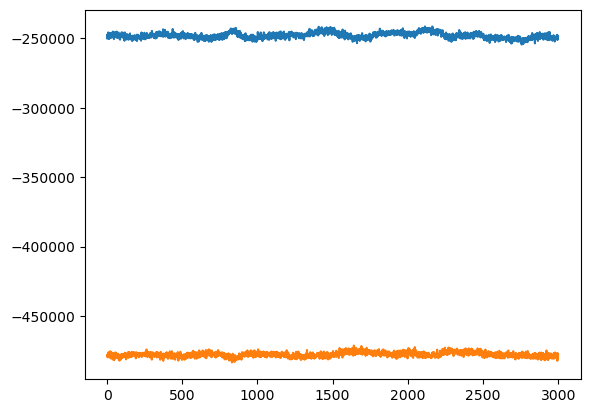

2.603790912
29297


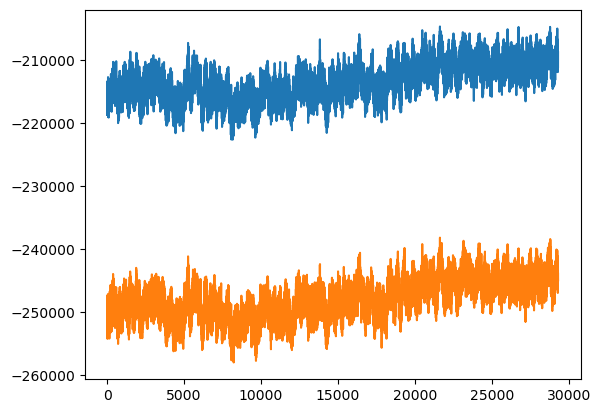

In [360]:
fig, ax = plt.subplots()
ax.plot(np.real(buffer_np[3,:3000]))
ax.plot(np.imag(buffer_np[3,:3000]))
plt.show()

time_domain = np.arange(buffer_np.shape[1]) / (5e9 / 320)
print(time_domain[-1])
mask = (time_domain >= 0.5200) & (time_domain < 0.521875)
print(mask.sum())

fig, ax = plt.subplots()
ax.plot(np.real(buffer_np[2,mask]))
ax.plot(np.real(buffer_np[3,mask]))
plt.show()

In [361]:
print(first_ts/ACLK_FREQ)
print(edge_times.shape)
print(edge_times[0])

11316.23142928
(5000, 2)
[11316.23171536 11316.23221618]


In [362]:
dc_data = process_to_dc(buffer_np, 5e9 / 320, fft_bins=10)

New number of samples (after FFT binning): 40684230
Finishesd FFTing


In [363]:
print(dc_data.shape)
print(edge_times.shape)
print(dc_data.dtype)

(4, 40684230)
(5000, 2)
float64


In [364]:
# fig, ax = plt.subplots()
# ax.plot(dc_data[2,:])
# plt.show()

print(dc_data[2].std())
print(dc_data[3].std())

2562.744498115721
2698.793398089396


In [365]:
time_domain = first_ts/ACLK_FREQ + np.arange(dc_data.shape[1]) / (5e9 / 320)
integrated_data = gate_means(dc_data, time_domain, edge_times)

In [366]:
print(integrated_data.shape)
print(integrated_data[2])

(4, 4998)
[512155.15552428 511659.77274055 510566.65540485 ... 511800.4461896
 511369.9435186  511794.79483702]


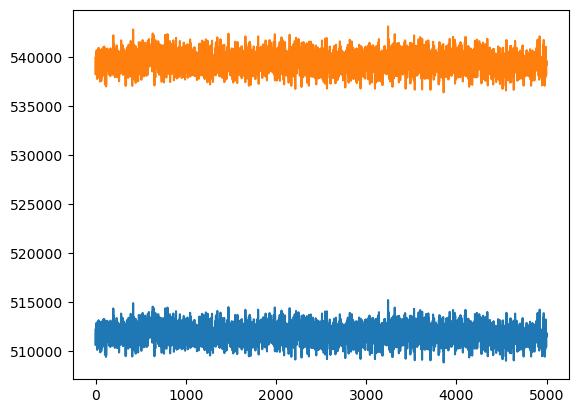

In [367]:
fig, ax = plt.subplots()
ax.plot(integrated_data[2])
ax.plot(integrated_data[3])
plt.show()

In [368]:
if integrated_data.shape[1]%2 != 0:
    integrated_data = integrated_data[:,:-1]

even_mask = np.arange(integrated_data.shape[1])%2 == 0
rdfs = (integrated_data[:,even_mask] - integrated_data[:,~even_mask]) / (integrated_data[:,even_mask] + integrated_data[:,~even_mask]) 
print(rdfs.shape)

(4, 2499)


1208.9194834057264
1208.4535678216855


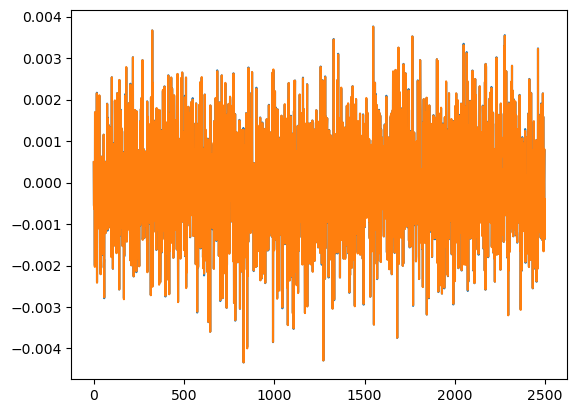

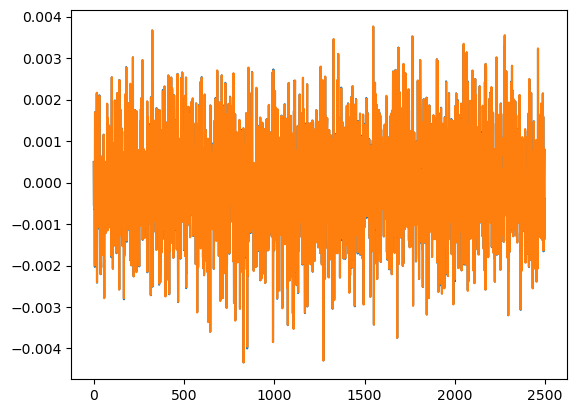

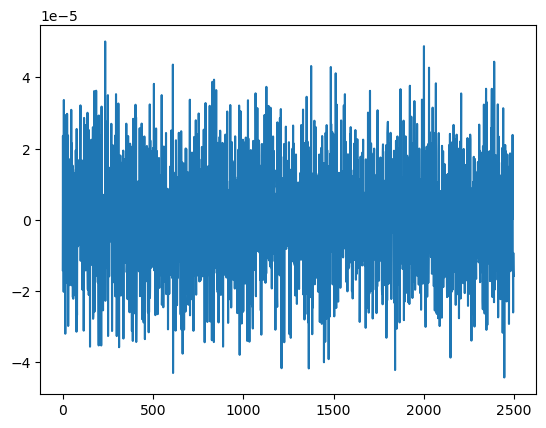

[-9.91584746e-06  5.71750529e-04  7.96263827e-04 -1.36874410e-03
 -4.15232565e-04]


In [369]:
ddfs = rdfs[2] - rdfs[3]
# ddfs = ddfs[:-1]
print(rdfs[2].std()*1e6)
print(rdfs[3].std()*1e6)

fig, ax = plt.subplots()
ax.plot(rdfs[2])
ax.plot(rdfs[3])
plt.show()

fig, ax = plt.subplots()
ax.plot(rdfs[3])
ax.plot(rdfs[2])
plt.show()

fig, ax = plt.subplots()
ax.plot(ddfs)
plt.show()

print(rdfs[2][-5:])

In [370]:
# print(dc_data.shape)
# fig, ax = plt.subplots()
# ax.plot(dc_data[2][-5000:])
# plt.show()

In [371]:
print(ddfs.mean())
print(ddfs.std()*1e6 * 1/np.sqrt(2))

3.1896094925333537e-07
10.473599339615479


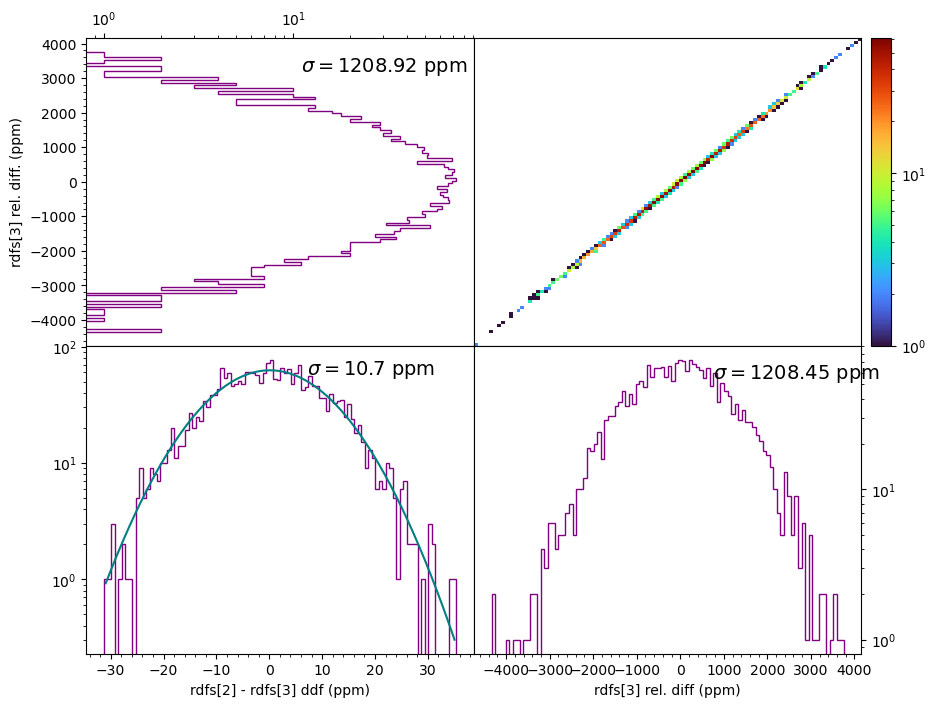

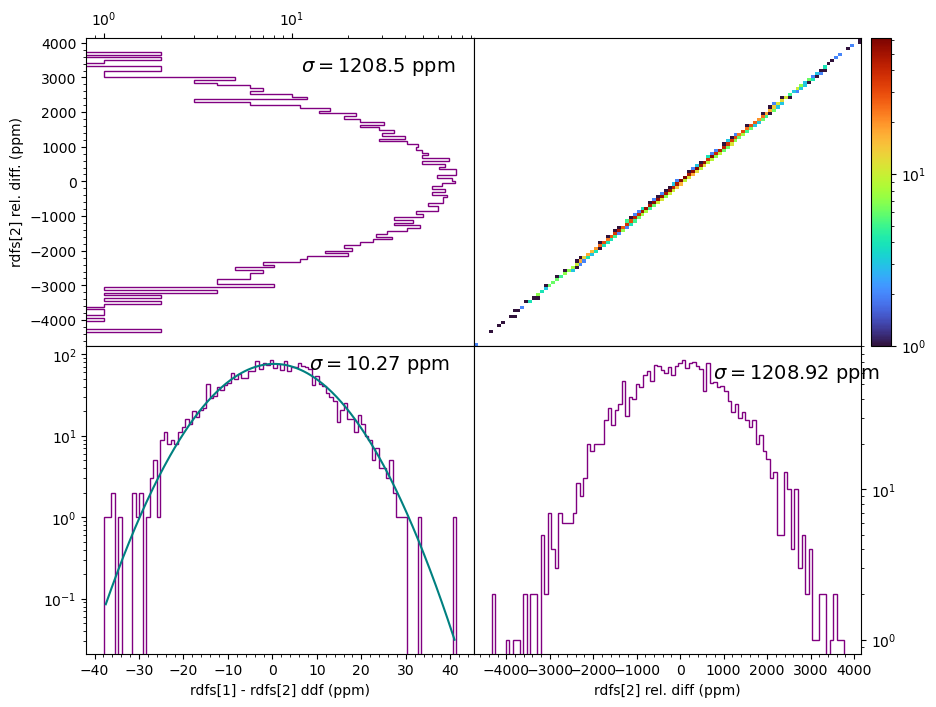

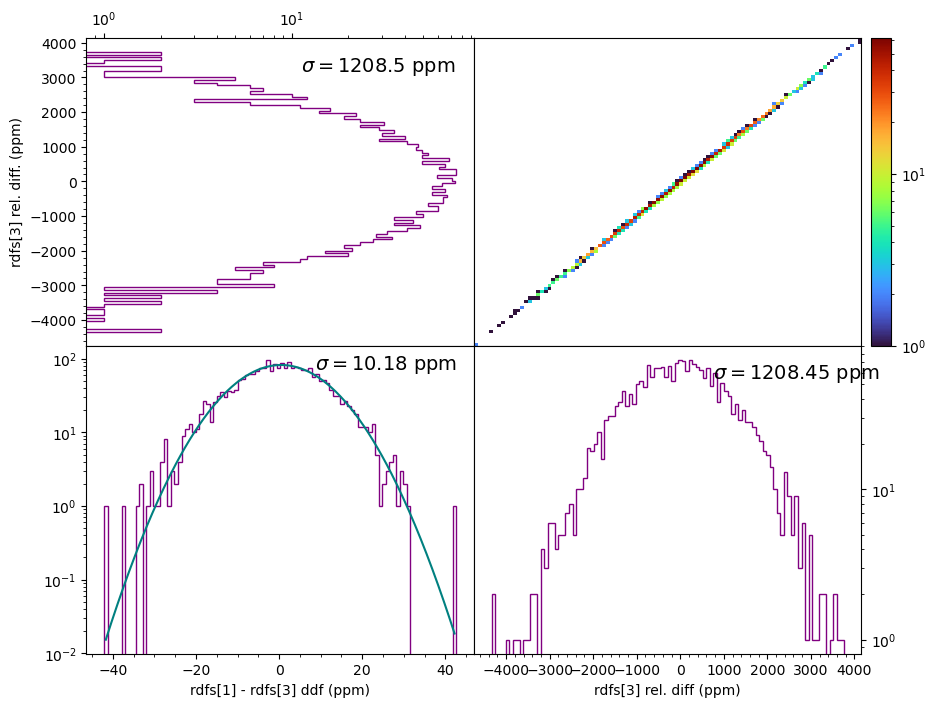

In [372]:
plot_nice_ddf(ddfs*1e6/np.sqrt(2), rdfs[2]*1e6, rdfs[3]*1e6, 'rdfs[2]', 'rdfs[3]', 'asdf')
plot_nice_ddf((rdfs[1]-rdfs[2])*1e6/np.sqrt(2), rdfs[1]*1e6, rdfs[2]*1e6, 'rdfs[1]', 'rdfs[2]', 'asdf')
plot_nice_ddf((rdfs[1]-rdfs[3])*1e6/np.sqrt(2), rdfs[1]*1e6, rdfs[3]*1e6, 'rdfs[1]', 'rdfs[3]', 'asdf')

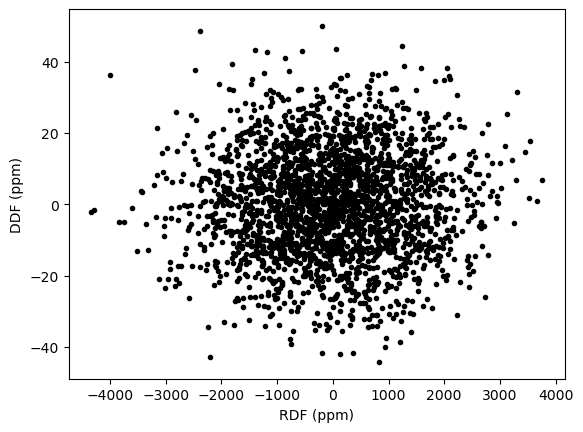

In [373]:
fig, ax = plt.subplots()
ax.scatter(rdfs[3]*1e6, ddfs*1e6, marker='.', color='black')
ax.set_xlabel('RDF (ppm)')
ax.set_ylabel('DDF (ppm)')
plt.show()

   -4133  mean= 10.955  se=12.727  (+0.9 sigma)
   -3729  mean= -3.647  se= 1.287  (-2.8 sigma)
   -3324  mean=  0.765  se= 3.637  (+0.2 sigma)
   -2920  mean= -5.625  se= 3.014  (-1.9 sigma)
   -2515  mean=  2.959  se= 2.649  (+1.1 sigma)
   -2110  mean= -1.425  se= 1.486  (-1.0 sigma)
   -1706  mean= -0.502  se= 1.258  (-0.4 sigma)
   -1301  mean=  0.908  se= 1.114  (+0.8 sigma)
    -897  mean= -1.024  se= 0.926  (-1.1 sigma)
    -492  mean=  1.375  se= 0.784  (+1.8 sigma)
     -87  mean=  0.367  se= 0.812  (+0.5 sigma)
     317  mean=  0.156  se= 0.823  (+0.2 sigma)
     722  mean=  0.493  se= 0.968  (+0.5 sigma)
    1127  mean= -0.171  se= 1.117  (-0.2 sigma)
    1531  mean=  0.549  se= 1.182  (+0.5 sigma)
    1936  mean=  1.281  se= 1.531  (+0.8 sigma)
    2340  mean= -0.014  se= 2.083  (-0.0 sigma)
    2745  mean=  1.013  se= 2.361  (+0.4 sigma)
    3150  mean=  9.710  se= 3.371  (+2.9 sigma)
    3554  mean=  8.714  se= 4.369  (+2.0 sigma)


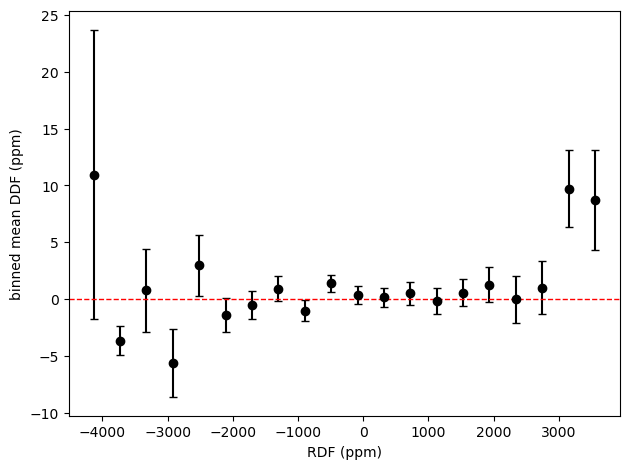

In [374]:
import numpy as np
import matplotlib.pyplot as plt

rdf = rdfs[3]*1e6
ddf = ddfs*1e6

bins = np.linspace(rdf.min(), rdf.max(), 21)
idx = np.digitize(rdf, bins)

centers, means, ses = [], [], []
for b in range(1, len(bins)):
    sel = idx == b
    n = sel.sum()
    if n > 1:
        m = ddf[sel].mean()
        se = ddf[sel].std(ddof=1) / np.sqrt(n)
        center = 0.5 * (bins[b-1] + bins[b])
        centers.append(center)
        means.append(m)
        ses.append(se)
        print(f"{center:8.0f}  mean={m:7.3f}  se={se:6.3f}  ({m/se:+.1f} sigma)")

centers = np.array(centers)
means = np.array(means)
ses = np.array(ses)

plt.figure()
plt.errorbar(centers, means, yerr=ses, fmt='o', capsize=3, color='black')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('RDF (ppm)')
plt.ylabel('binned mean DDF (ppm)')
plt.tight_layout()
plt.show()